# FASE 4: Procesamiento de datos IoT en tiempo real

###Santiago Mosquera y Samuel Rengifo

**Proyecto:** Sistema de monitoreo de sensores IoT y analítica de datos agroclimáticos  
**Cultivos:** Caña de azúcar (Valle del Cauca) y Arroz (Tolima, Casanare)  
**Curso:** Sistemas y Comunicaciones I — Universidad ICESI  
**Fase:** 4 — Procesamiento de datos IoT en tiempo real

---

## Objetivo

Implementar un pipeline de procesamiento en tiempo real que reciba los mensajes MQTT del simulador (Fase 2), los limpie, transforme, calcule indicadores agroclimáticos derivados, y los persista de forma organizada en InfluxDB (Fase 3). El sistema produce **dos capas de datos**: las mediciones limpias y los indicadores calculados.

## Arquitectura del pipeline (5 etapas)

```
Sensores (Fase 2)
    │ MQTT
    ▼
Mosquitto
    │
    ▼
Node-RED Gateway:
  ┌───────────────┐  ┌──────────────────┐  ┌─────────────────────────┐  ┌──────────────────────┐  ┌──────────────────┐
  │ 1. Limpieza   │→ │ 2. Transformación │→ │ 3. Indicadores agroclim. │→ │ 4. Variables derivadas │→ │ 5. Persistencia  │
  │  - rango fís. │  │  - unidades       │  │  - Heat Index           │  │  - ETo (FAO-56)       │  │  - 2 buckets      │
  │  - NaN/dups   │  │  - metadata       │  │  - Punto de rocío       │  │    Hargreaves         │  │  Influx v2        │
  │               │  │  - ISO timestamps │  │  - VPD (FAO-56)         │  │                       │  │                   │
  │               │  │                   │  │  - GDD                  │  │                       │  │                   │
  └───────────────┘  └──────────────────┘  └─────────────────────────┘  └──────────────────────┘  └──────────────────┘
                                                                                                          │
                                                            ┌─────────────────────────────────────────────┘
                                                            ▼
                                                  Bucket: agro_iot_data        ←─ mediciones limpias
                                                  Bucket: agro_iot_indicadores ←─ indicadores calculados (Fase 5 los consume)
```

## Diferencias con la Fase 3

- **Etapa de limpieza explícita:** validación de rangos físicos por variable, eliminación de NaN, deduplicación.
- **Enriquecimiento con metadata:** departamento, altitud (consistentes con la Fase 1).
- **Indicadores agroclimáticos derivados:** Heat Index, Dew Point, VPD, GDD, ETo — variables que NO miden los sensores directamente pero que son críticas para la toma de decisiones agronómicas.
- **Segundo bucket dedicado:** `agro_iot_indicadores`, con retención mayor (365 días) porque los indicadores son la base de las alertas y el análisis histórico.

## ¿Por qué este diseño es bueno para la Fase 5?

La Fase 5 (alertas) NO necesita reprocesar mediciones crudas: simplemente consulta el bucket `agro_iot_indicadores` y aplica umbrales. Esto desacopla el procesamiento de la alerta, mejora el rendimiento y facilita el mantenimiento.

---
## 1. Verificación de prerrequisitos

In [ ]:
# Verificación de servicios y dependencias
import os
import socket
from pathlib import Path

try:
    from influxdb_client import InfluxDBClient, Point, WritePrecision
    from influxdb_client.client.write_api import SYNCHRONOUS
    print('✓ influxdb-client disponible')
except ImportError:
    print('✗ Instalar: pip install influxdb-client')

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    print(f'✓ pandas {pd.__version__}, numpy {np.__version__}')
except ImportError:
    print('✗ Instalar: pip install pandas numpy matplotlib')

def port_open(host, port, timeout=2):
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except (socket.timeout, ConnectionRefusedError, OSError):
        return False

for name, host, port in [('Mosquitto', 'localhost', 1883),
                          ('InfluxDB',  'localhost', 8086),
                          ('Node-RED',  'localhost', 1880)]:
    estado = '✓ activo' if port_open(host, port) else '✗ inactivo'
    print(f'  {name:10s} {host}:{port:<5d} {estado}')

if Path('flow_node_red_fase4.json').exists():
    print('✓ flow_node_red_fase4.json disponible')
else:
    print('⚠ flow_node_red_fase4.json no se encuentra')

✓ influxdb-client disponible
✓ pandas 3.0.2, numpy 2.4.4
  Mosquitto  localhost:1883  ✓ activo
  InfluxDB   localhost:8086  ✓ activo
  Node-RED   localhost:1880  ✓ activo
✓ flow_node_red_fase4.json disponible


---
## 2. Implementación de las 4 etapas de procesamiento en Python

Las mismas funciones que están escritas en JavaScript en los nodos `function` de Node-RED se replican aquí en Python. Esto permite:

1. Validar la lógica de procesamiento de forma aislada (testing).
2. Procesar datos históricos del CSV de Fase 1 sin atravesar Node-RED.
3. Comparar el output Python vs el output del flow Node-RED en producción.

### Etapa 1 — Limpieza

In [ ]:
import math
from datetime import datetime, timezone
from typing import Optional

# Rangos físicos por variable (NO son rangos agronómicos)
RANGOS_FISICOS = {
    'temperatura_aire':  (-20, 55),
    'temperatura_suelo': (-20, 60),
    'humedad_relativa':  (0, 100),
    'humedad_suelo':     (0, 100),
    'precipitacion':     (0, 500),
    'radiacion_solar':   (0, 40),
    'velocidad_viento':  (0, 50),
    'ph_suelo':          (0, 14),
}

def etapa1_limpieza(msg: dict, cache_dedup: dict) -> Optional[dict]:
    """Valida estructura, rangos físicos y deduplica mensajes.

    Returns None si el mensaje debe descartarse, o el mensaje validado.
    """
    # a) Tópicos de sistema → descartar
    topic = msg.get('topico', '')
    if topic.startswith('agricultura/sistema/'):
        return None

    # b) Estructura mínima
    if not msg.get('variable') or msg.get('valor') is None:
        return None

    # c) Valor numérico finito
    try:
        v = float(msg['valor'])
    except (TypeError, ValueError):
        return None
    if not math.isfinite(v):
        return None

    # d) Rango físico
    rango = RANGOS_FISICOS.get(msg['variable'])
    if rango and not (rango[0] <= v <= rango[1]):
        return None

    # e) Deduplicación leve (1s window por sensor_id + valor)
    key = f"{msg.get('sensor_id', '')}:{round(v, 3)}"
    now = datetime.now(timezone.utc).timestamp()
    if key in cache_dedup and (now - cache_dedup[key]) < 1.0:
        return None
    cache_dedup[key] = now

    msg['valor'] = v
    return msg

# Test con mensaje válido
msg_test = {
    'topico': 'agricultura/caña/parcela_1/temperatura_aire',
    'variable': 'temperatura_aire', 'valor': 23.97,
    'parcela': 'parcela_1', 'cultivo': 'caña', 'ubicacion': 'Palmira_VAC',
    'unidad': '°C', 'sensor_id': 'parcela_1_temperatura_aire',
    'timestamp_real': '2026-05-13T17:34:56Z'
}
cache = {}
resultado = etapa1_limpieza(dict(msg_test), cache)
print(f'Mensaje válido pasa la etapa 1: {resultado is not None}')

# Test con mensaje inválido (temperatura imposible)
msg_malo = dict(msg_test); msg_malo['valor'] = -999
resultado_malo = etapa1_limpieza(msg_malo, cache)
print(f'Mensaje fuera de rango físico se descarta: {resultado_malo is None}')

# Test con duplicado
resultado_dup = etapa1_limpieza(dict(msg_test), cache)
print(f'Duplicado dentro de ventana 1s se descarta: {resultado_dup is None}')

Mensaje válido pasa la etapa 1: True
Mensaje fuera de rango físico se descarta: True
Duplicado dentro de ventana 1s se descarta: True


### Etapa 2 — Transformación

In [ ]:
# Metadata estática por parcela — alineada con coordenadas de Fase 1 (IGAC)
META_PARCELA = {
    'parcela_1': {'departamento': 'Valle del Cauca', 'altitud_m': 1001},
    'parcela_2': {'departamento': 'Valle del Cauca', 'altitud_m': 980},
    'parcela_3': {'departamento': 'Tolima',          'altitud_m': 323},
    'parcela_4': {'departamento': 'Casanare',        'altitud_m': 350},
}

def etapa2_transformacion(msg: dict) -> dict:
    """Normaliza unidades, enriquece con metadata y estandariza timestamps."""
    meta = META_PARCELA.get(msg.get('parcela'), {'departamento': 'desconocido', 'altitud_m': 0})
    msg['departamento'] = meta['departamento']
    msg['altitud_m']    = meta['altitud_m']

    # Conversiones defensivas de unidades
    if msg.get('variable') == 'velocidad_viento' and msg.get('unidad') == 'km/h':
        msg['valor'] = msg['valor'] / 3.6
        msg['unidad'] = 'm/s'
    if msg.get('variable') in ('temperatura_aire', 'temperatura_suelo') and msg.get('unidad') == '°F':
        msg['valor'] = (msg['valor'] - 32) * 5 / 9
        msg['unidad'] = '°C'

    # Timestamp normalizado
    if 'timestamp_real' in msg:
        try:
            ts = datetime.fromisoformat(msg['timestamp_real'].replace('Z', '+00:00'))
            msg['timestamp_iso'] = ts.astimezone(timezone.utc).isoformat()
        except Exception:
            msg['timestamp_iso'] = datetime.now(timezone.utc).isoformat()
    return msg

# Test
msg_t2 = etapa2_transformacion(dict(msg_test))
print('Mensaje enriquecido:')
for k, v in msg_t2.items():
    print(f'  {k}: {v}')

Mensaje enriquecido:
  topico: agricultura/caña/parcela_1/temperatura_aire
  variable: temperatura_aire
  valor: 23.97
  parcela: parcela_1
  cultivo: caña
  ubicacion: Palmira_VAC
  unidad: °C
  sensor_id: parcela_1_temperatura_aire
  timestamp_real: 2026-05-13T17:34:56Z
  departamento: Valle del Cauca
  altitud_m: 1001
  timestamp_iso: 2026-05-13T17:34:56+00:00


### Etapa 3 — Cálculo de indicadores agroclimáticos

Cinco indicadores se calculan cuando hay datos frescos disponibles:

1. **Índice de calor** (Heat Index) — sensación térmica
2. **Punto de rocío** (Dew Point) — riesgo de condensación
3. **VPD** (Vapor Pressure Deficit) — estrés hídrico foliar (FAO-56)
4. **GDD** (Growing Degree Days) — acumulación térmica fenológica
5. **ETo** (evapotranspiración de referencia) — Hargreaves FAO-56

## Referencias de ecuaciones agroclimáticas utilizadas

En esta sección se documentan las fuentes bibliográficas y las variables utilizadas para el cálculo de los indicadores agroclimáticos implementados en el pipeline de procesamiento IoT. Las ecuaciones fueron seleccionadas por su uso frecuente en monitoreo agroclimático, agricultura digital y análisis de estrés ambiental en cultivos de caña de azúcar y arroz.

---

### 1. Índice de calor (Heat Index)

Indicador utilizado para estimar la sensación térmica a partir de la temperatura del aire y la humedad relativa.

**Variables utilizadas:**

- $T$: temperatura del aire
- $RH$: humedad relativa

**Fuente de la ecuación:**

National Weather Service (NWS) — Rothfusz Regression Equation

https://www.wpc.ncep.noaa.gov/html/heatindex_equation.shtml

**Ecuación documentada por NWS:**

$
HI = -42.379 + 2.04901523T + 10.14333127RH
- 0.22475541TRH - 0.00683783T^2
- 0.05481717RH^2 + 0.00122874T^2RH
+ 0.00085282TRH^2 - 0.00000199T^2RH^2
$

---

### 2. Punto de rocío (Dew Point)

Indicador utilizado para estimar el riesgo de condensación y saturación de humedad en el ambiente.

**Variables utilizadas:**

- $T$: temperatura del aire
- $RH$: humedad relativa
- $a$: constante empírica de la aproximación Magnus-Tetens
- $b$: constante empírica de la aproximación Magnus-Tetens

Las constantes empíricas utilizadas corresponden a la aproximación Magnus-Tetens para vapor de agua sobre superficies líquidas en condiciones atmosféricas normales:

- $a = 17.27$
- $b = 237.7 \ ^\circ C$

Estas constantes fueron obtenidas experimentalmente para aproximar el comportamiento de la presión de vapor de saturación del agua en función de la temperatura y son ampliamente utilizadas en meteorología, agroclimatología y ciencias atmosféricas.

**Fuente de la ecuación:**

Kestrel Instruments — Magnus-Tetens Approximation

https://kestrelinstruments.com/blog/what-is-the-dew-point-and-how-is-it-calculated

**Ecuaciones documentadas:**

$
Td = \frac{b \cdot \alpha(T,RH)}{a - \alpha(T,RH)}
$

$
\alpha(T,RH)=\frac{aT}{b+T}+\ln\left(\frac{RH}{100}\right)
$

---

### 3. Déficit de presión de vapor (VPD)

Indicador utilizado para estimar el estrés hídrico atmosférico y la demanda evaporativa sobre el cultivo.

**Variables utilizadas:**

- $T$: temperatura del aire
- $RH$: humedad relativa
- $e_s$: presión de vapor de saturación
- $e_a$: presión de vapor actual

**Fuente de la ecuación:**

FAO-56 — Crop Evapotranspiration

https://www.professormendoncauenf.com.br/wp-content/uploads/2021/03/ag_fao_56_ingles.pdf

**Ecuaciones utilizadas:**

Presión de vapor de saturación (Eq. 11):

$
e_s = 0.6108 \cdot e^{\left(\frac{17.27T}{T+237.3}\right)}
$

Presión de vapor actual (Eq. 19):

$
e_a = e_s \cdot \frac{RH}{100}
$

Déficit de presión de vapor:

$
VPD = e_s - e_a
$

---

### 4. Growing Degree Days (GDD)

Indicador utilizado para estimar acumulación térmica y desarrollo fenológico del cultivo.

**Variables utilizadas:**

- $T_{MAX}$: temperatura máxima diaria
- $T_{MIN}$: temperatura mínima diaria
- $T_{BASE}$: temperatura base del cultivo

**Fuente de la ecuación:**

McMaster & Wilhelm — Growing Degree-Days

https://digitalcommons.unl.edu/usdaarsfacpub/83/

**Ecuación documentada:**

$
GDD = \left(\frac{T_{MAX}+T_{MIN}}{2}\right)-T_{BASE}
$

Para el cálculo instantáneo implementado en el pipeline se utiliza la temperatura disponible en tiempo real:

$
GDD = \max(0, T - T_{BASE})
$

---

### 5. Evapotranspiración de referencia (ETo) — Hargreaves FAO-56

Indicador utilizado para estimar la demanda hídrica atmosférica y las necesidades potenciales de riego.

**Variables utilizadas:**

- $T_{mean}$: temperatura media diaria
- $T_{max}$: temperatura máxima diaria
- $T_{min}$: temperatura mínima diaria
- $R_a$: radiación extraterrestre

**Fuente de la ecuación:**

FAO-56 — Crop Evapotranspiration (Equation 52)

https://www.fao.org/4/X0490E/x0490e00.htm

**Ecuación utilizada:**

$
ET_o = 0.0023(T_{mean}+17.8)\sqrt{T_{max}-T_{min}} \cdot R_a \cdot 0.408
$


In [ ]:
def heat_index(T_C: float, RH: float) -> float:
    """Índice de calor NWS Steadman/Rothfusz (°C)."""
    Tf = T_C * 9/5 + 32
    if Tf < 80:
        HIf = 0.5 * (Tf + 61.0 + (Tf - 68.0)*1.2 + RH*0.094)
    else:
        HIf = (-42.379 + 2.04901523*Tf + 10.14333127*RH
               - 0.22475541*Tf*RH - 0.00683783*Tf*Tf
               - 0.05481717*RH*RH + 0.00122874*Tf*Tf*RH
               + 0.00085282*Tf*RH*RH - 0.00000199*Tf*Tf*RH*RH)
    return (HIf - 32) * 5/9

def dew_point(T: float, RH: float) -> float:
    """Punto de rocío Magnus-Tetens (°C)."""
    a, b = 17.625, 243.04
    alpha = math.log(max(RH, 0.01) / 100) + a * T / (b + T)
    return (b * alpha) / (a - alpha)

def vpd(T: float, RH: float) -> float:
    """Déficit de presión de vapor (kPa) — FAO-56."""
    es = 0.6108 * math.exp(17.27 * T / (T + 237.3))
    ea = es * RH / 100
    return es - ea

def gdd_instantaneo(T: float, T_base: float) -> float:
    """Grados-día de crecimiento instantáneo (°C·día)."""
    return max(0, T - T_base)

# Validar con los promedios reales de Fase 1 por parcela
parcelas_test = [
    ('Palmira_VAC',    'caña',  23.97, 80.0, 18.0),
    ('Candelaria_VAC', 'caña',  24.17, 76.0, 18.0),
    ('Espinal_TOL',    'arroz', 27.34, 73.0, 10.0),
    ('Yopal_CAS',      'arroz', 26.70, 70.0, 10.0),
]
print(f'{"Ubicación":18s} {"Cult.":6s} {"T°":>6s} {"HR":>5s} {"HI":>7s} {"DP":>7s} {"VPD":>7s} {"GDD":>6s}')
print('-' * 70)
for ubic, cult, T, RH, Tb in parcelas_test:
    HI = heat_index(T, RH)
    DP = dew_point(T, RH)
    VP = vpd(T, RH)
    GDD = gdd_instantaneo(T, Tb)
    print(f'{ubic:18s} {cult:6s} {T:5.2f}° {RH:4.0f}% {HI:6.2f}° {DP:6.2f}° {VP:5.3f}kPa {GDD:5.2f}°·d')

print()
print('Interpretación agronómica:')
print('  • VPD 0.4-1.0 kPa = óptimo | 1.0-1.6 = estrés moderado | >1.6 = severo')
print('  • Arroz tiene mayor VPD por menor altitud → mayor demanda hídrica diurna')
print('  • GDD arroz alto por T_base baja → 10°C es típico de Oryza sativa (FEDEARROZ)')
print('  • DP cercano a T° (RH alta) → riesgo de condensación nocturna en hojas')

Ubicación          Cult.      T°    HR      HI      DP     VPD    GDD
----------------------------------------------------------------------
Palmira_VAC        caña   23.97°   80%  24.51°  20.31° 0.596kPa  5.97°·d
Candelaria_VAC     caña   24.17°   76%  24.63°  19.67° 0.723kPa  6.17°·d
Espinal_TOL        arroz  27.34°   73%  29.75°  22.07° 0.982kPa 17.34°·d
Yopal_CAS          arroz  26.70°   70%  28.36°  20.77° 1.051kPa 16.70°·d

Interpretación agronómica:
  • VPD 0.4-1.0 kPa = óptimo | 1.0-1.6 = estrés moderado | >1.6 = severo
  • Arroz tiene mayor VPD por menor altitud → mayor demanda hídrica diurna
  • GDD arroz alto por T_base baja → 10°C es típico de Oryza sativa (FEDEARROZ)
  • DP cercano a T° (RH alta) → riesgo de condensación nocturna en hojas


In [ ]:
# Función agregadora — replica la etapa 3 del flow Node-RED
def etapa3_indicadores(msg: dict, cache_parcelas: dict, ts_actual: float) -> dict:
    """Calcula indicadores cuando hay datos frescos disponibles en cache.

    cache_parcelas estructura:
        { 'parcela_1': { 'temperatura_aire': {'v': 23.97, 't': <epoch>}, ... }, ... }
    """
    parcela = msg.get('parcela')
    if not parcela:
        return msg
    cache_parcelas.setdefault(parcela, {})
    cache_parcelas[parcela][msg['variable']] = {'v': msg['valor'], 't': ts_actual}

    pc = cache_parcelas[parcela]
    FRESCO_MAX = 10 * 60   # 10 min en segundos
    def fresco(k):
        return k in pc and (ts_actual - pc[k]['t']) <= FRESCO_MAX

    indicadores = []
    if fresco('temperatura_aire') and fresco('humedad_relativa'):
        T = pc['temperatura_aire']['v']
        RH = pc['humedad_relativa']['v']
        indicadores.append({'nombre': 'indice_calor', 'valor': round(heat_index(T, RH), 2), 'unidad': '°C'})
        indicadores.append({'nombre': 'punto_rocio',  'valor': round(dew_point(T, RH), 2), 'unidad': '°C'})
        indicadores.append({'nombre': 'vpd',          'valor': round(vpd(T, RH), 3),       'unidad': 'kPa'})
    if fresco('temperatura_aire'):
        T = pc['temperatura_aire']['v']
        Tb = 18.0 if msg.get('cultivo') == 'caña' else 10.0
        indicadores.append({'nombre': 'gdd_instantaneo', 'valor': round(gdd_instantaneo(T, Tb), 2),
                             'unidad': '°C·día', 'meta': {'t_base': Tb}})
    msg['indicadores'] = indicadores
    return msg

print('Función etapa3_indicadores definida.')

Función etapa3_indicadores definida.


### Etapa 4 — Variable derivada: ETo (Hargreaves FAO-56)

In [ ]:
def eto_hargreaves(T_mean: float, T_max: Optional[float] = None,
                     T_min: Optional[float] = None, Ra: float = 36.0) -> float:
    """Evapotranspiración de referencia (mm/día) por FAO-56 ec. 52.

    Parameters
    ----------
    T_mean : temperatura media diaria (°C)
    T_max, T_min : temperatura máxima y mínima (°C); si no se proveen, se
                   estiman como T_mean ± 5°C (amplitud diaria típica tropical).
    Ra : radiación extraterrestre (MJ/m²/día); 36.0 ≈ promedio anual ecuatorial.
    """
    if T_max is None: T_max = T_mean + 5
    if T_min is None: T_min = T_mean - 5
    Tdiff = max(T_max - T_min, 0.1)
    return 0.0023 * (T_mean + 17.8) * math.sqrt(Tdiff) * Ra * 0.408

def etapa4_derivadas(msg: dict, cache_parcelas: dict) -> dict:
    pc = cache_parcelas.get(msg.get('parcela', ''), {})
    if 'temperatura_aire' in pc:
        T = pc['temperatura_aire']['v']
        Tmax = pc.get('temperatura_aire_max', {}).get('v', T + 5)
        Tmin = pc.get('temperatura_aire_min', {}).get('v', T - 5)
        ETo = eto_hargreaves(T, Tmax, Tmin)
        msg.setdefault('indicadores', []).append({
            'nombre': 'eto_hargreaves',
            'valor': round(ETo, 3),
            'unidad': 'mm/día',
            'meta': {'metodo': 'Hargreaves FAO-56', 'Ra_MJm2dia': 36.0}
        })
    return msg

# Demostración del pipeline completo con un lote de mensajes
import time
ahora = time.time()
cache_p = {}
cache_d = {}
mensajes_demo = [
    {'topico': 'agricultura/caña/parcela_1/temperatura_aire',  'parcela': 'parcela_1', 'cultivo': 'caña',
     'ubicacion': 'Palmira_VAC', 'variable': 'temperatura_aire', 'valor': 23.97, 'unidad': '°C',
     'sensor_id': 'parcela_1_temperatura_aire', 'timestamp_real': '2026-05-13T17:34:56Z'},
    {'topico': 'agricultura/caña/parcela_1/humedad_relativa', 'parcela': 'parcela_1', 'cultivo': 'caña',
     'ubicacion': 'Palmira_VAC', 'variable': 'humedad_relativa', 'valor': 80.0, 'unidad': '%',
     'sensor_id': 'parcela_1_humedad_relativa', 'timestamp_real': '2026-05-13T17:34:57Z'},
]
for m in mensajes_demo:
    m1 = etapa1_limpieza(m, cache_d)
    if not m1: continue
    m2 = etapa2_transformacion(m1)
    m3 = etapa3_indicadores(m2, cache_p, ahora)
    m4 = etapa4_derivadas(m3, cache_p)

print('Indicadores generados para parcela_1 (Palmira_VAC) tras procesar T°+RH:')
for ind in m4.get('indicadores', []):
    print(f"  • {ind['nombre']:18s} = {ind['valor']:>8} {ind['unidad']}")

Indicadores generados para parcela_1 (Palmira_VAC) tras procesar T°+RH:
  • indice_calor       =    24.51 °C
  • punto_rocio        =    20.31 °C
  • vpd                =    0.596 kPa
  • gdd_instantaneo    =     5.97 °C·día
  • eto_hargreaves     =    4.462 mm/día


---
## 3. Procesamiento batch sobre el dataset histórico (Fase 1)

Para validar el pipeline completo, lo aplicamos al dataset histórico generado en la Fase 1. Esto produce los indicadores para los 18 años de datos diarios × 8 ubicaciones, demostrando que el procesamiento escala.

In [ ]:
# Cargar dataset de Fase 1 (debe estar en el mismo directorio)
DATASET = 'dataset_agroclimatico_colombia.csv'
if not Path(DATASET).exists():
    print(f'⚠ {DATASET} no encontrado — copiar el archivo de la Fase 1 a este directorio.')
else:
    df = pd.read_csv(DATASET, parse_dates=['fecha'])
    print(f'✓ Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')
    print(f'  Ubicaciones: {df["ubicacion"].nunique()}')
    print(f'  Periodo: {df["fecha"].min().date()} → {df["fecha"].max().date()}')

✓ Dataset cargado: 52,600 filas × 25 columnas
  Ubicaciones: 8
  Periodo: 2007-01-01 → 2024-12-31


In [ ]:
# Aplicar las fórmulas vectorizadas (más rápido que iterar)
import numpy as np

def heat_index_vec(T, RH):
    T = np.asarray(T); RH = np.asarray(RH)
    Tf = T * 9/5 + 32
    # Ramificación: pequeña aproximación para T baja, fórmula completa para T alta
    HIf_low = 0.5 * (Tf + 61.0 + (Tf - 68.0)*1.2 + RH*0.094)
    HIf_high = (-42.379 + 2.04901523*Tf + 10.14333127*RH
                - 0.22475541*Tf*RH - 0.00683783*Tf*Tf
                - 0.05481717*RH*RH + 0.00122874*Tf*Tf*RH
                + 0.00085282*Tf*RH*RH - 0.00000199*Tf*Tf*RH*RH)
    HIf = np.where(Tf < 80, HIf_low, HIf_high)
    return (HIf - 32) * 5/9

def dew_point_vec(T, RH):
    a, b = 17.625, 243.04
    alpha = np.log(np.maximum(RH, 0.01)/100) + a*T/(b+T)
    return b*alpha / (a-alpha)

def vpd_vec(T, RH):
    es = 0.6108 * np.exp(17.27*T/(T+237.3))
    return es * (1 - RH/100)

def eto_hargreaves_vec(Tmean, Tmax, Tmin, Ra=36.0):
    Tdiff = np.maximum(Tmax - Tmin, 0.1)
    return 0.0023 * (Tmean + 17.8) * np.sqrt(Tdiff) * Ra * 0.408

if Path(DATASET).exists():
    # Las columnas en el dataset usan el alias en español de Fase 1
    T    = df['temp_aire_avg_C'].values
    Tmax = df['temp_aire_max_C'].values
    Tmin = df['temp_aire_min_C'].values
    RH   = df['humedad_relativa_pct'].values

    df['indice_calor']     = heat_index_vec(T, RH).round(2)
    df['punto_rocio']      = dew_point_vec(T, RH).round(2)
    df['vpd']              = vpd_vec(T, RH).round(3)
    df['eto_hargreaves']   = eto_hargreaves_vec(T, Tmax, Tmin).round(3)
    # GDD diario: usa la media
    Tbase = np.where(df['cultivo'] == 'caña_de_azúcar', 18.0, 10.0)
    df['gdd_diario']       = np.maximum(0, T - Tbase).round(2)

    print('✓ Indicadores calculados para las {:,} filas'.format(len(df)))
    print('\nEstadísticas globales:')
    print(df[['indice_calor', 'punto_rocio', 'vpd', 'gdd_diario', 'eto_hargreaves']].describe().round(2))

✓ Indicadores calculados para las 52,600 filas

Estadísticas globales:
       indice_calor  punto_rocio       vpd  gdd_diario  eto_hargreaves
count      52600.00     52600.00  52600.00    52600.00        52600.00
mean          28.39        22.30      0.68       12.02            4.55
std            5.03         2.58      0.38        6.29            0.38
min           18.90        13.03      0.02        1.11            3.54
25%           24.51        20.47      0.40        5.88            4.28
50%           26.48        22.17      0.63       11.39            4.54
75%           31.87        24.04      0.91       18.11            4.81
max           55.59        31.82      2.36       24.13            5.87


In [ ]:
# Resumen por ubicación
if Path(DATASET).exists():
    resumen = df.groupby(['ubicacion', 'cultivo']).agg(
        T_media=('temp_aire_avg_C', 'mean'),
        RH_media=('humedad_relativa_pct', 'mean'),
        VPD_medio=('vpd', 'mean'),
        ETo_media=('eto_hargreaves', 'mean'),
        GDD_anual=('gdd_diario', lambda x: x.mean() * 365),
    ).round(2).reset_index()
    print('Resumen de indicadores agroclimáticos por ubicación:')
    print()
    resumen

Resumen de indicadores agroclimáticos por ubicación:



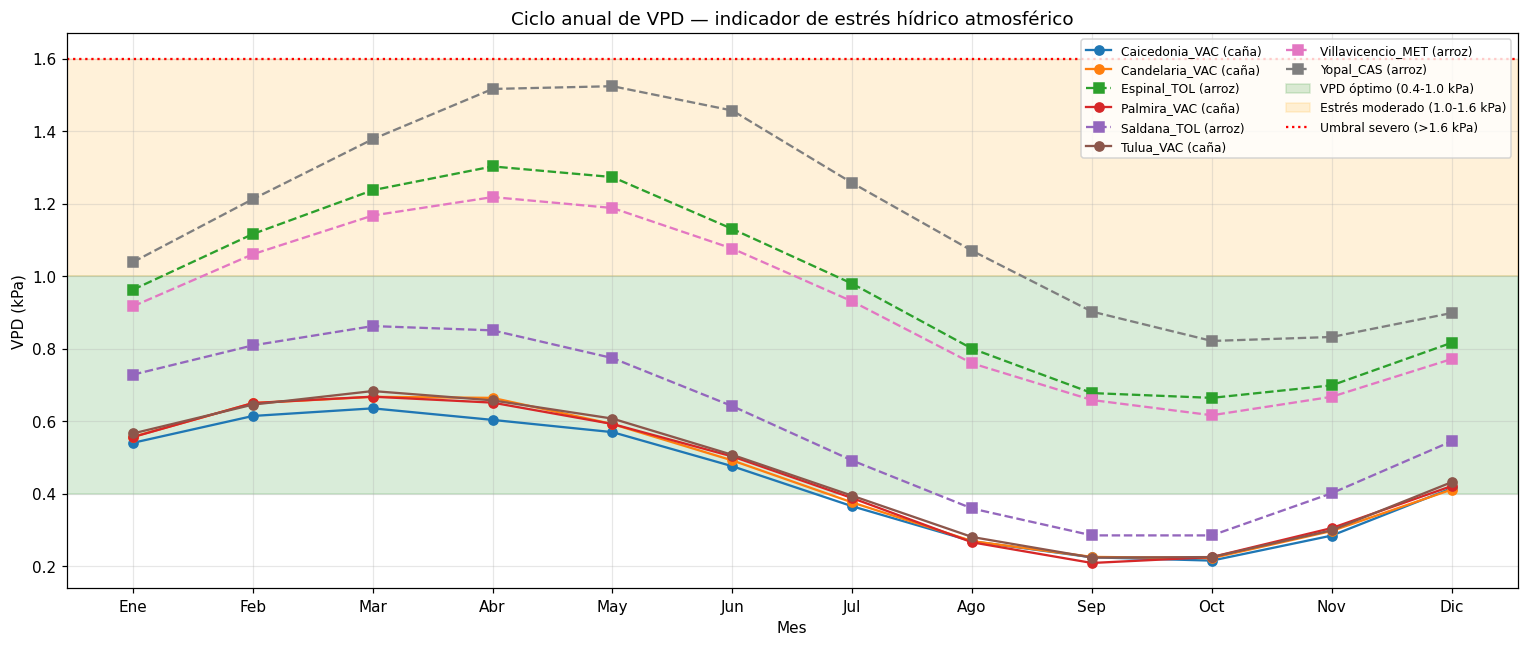

In [ ]:
# Visualización: VPD mensual por ubicación (indicador estrella de estrés hídrico)
import matplotlib.pyplot as plt
import seaborn as sns

if Path(DATASET).exists():
    df['mes'] = df['fecha'].dt.month
    vpd_mensual = df.groupby(['mes', 'ubicacion', 'cultivo'])['vpd'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    for ubic in vpd_mensual['ubicacion'].unique():
        sub = vpd_mensual[vpd_mensual['ubicacion'] == ubic]
        cult = sub['cultivo'].iloc[0]
        ls = '-' if cult == 'caña_de_azúcar' else '--'
        marker = 'o' if cult == 'caña_de_azúcar' else 's'
        ax.plot(sub['mes'], sub['vpd'], label=f'{ubic} ({cult.replace("_de_azúcar","")})',
                marker=marker, linestyle=ls, linewidth=1.5, markersize=6)
    ax.axhspan(0.4, 1.0, alpha=0.15, color='green', label='VPD óptimo (0.4-1.0 kPa)')
    ax.axhspan(1.0, 1.6, alpha=0.15, color='orange', label='Estrés moderado (1.0-1.6 kPa)')
    ax.axhline(1.6, color='red', linestyle=':', linewidth=1.5, label='Umbral severo (>1.6 kPa)')
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_es)
    ax.set_xlabel('Mes'); ax.set_ylabel('VPD (kPa)')
    ax.set_title('Ciclo anual de VPD — indicador de estrés hídrico atmosférico')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

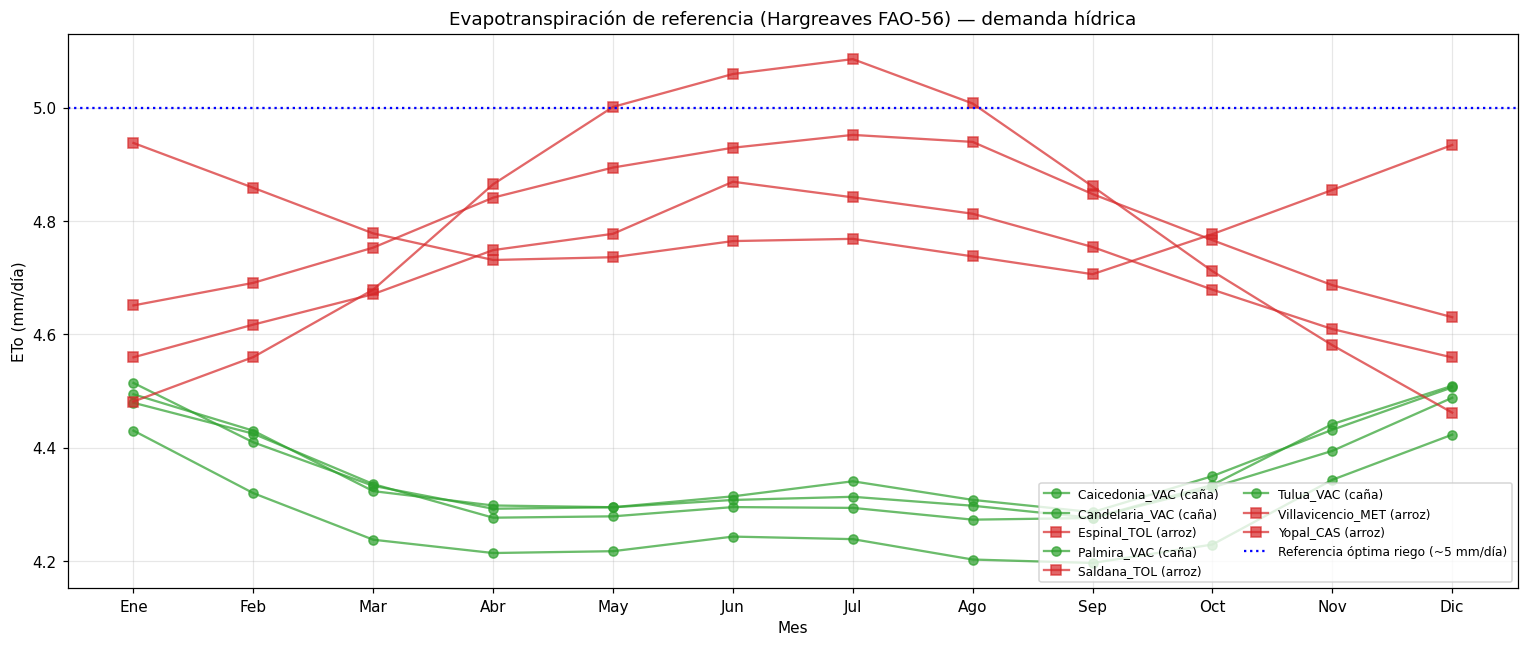

In [ ]:
# Visualización: ETo mensual por ubicación (demanda hídrica)
if Path(DATASET).exists():
    eto_mensual = df.groupby(['mes', 'ubicacion', 'cultivo'])['eto_hargreaves'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    for ubic in eto_mensual['ubicacion'].unique():
        sub = eto_mensual[eto_mensual['ubicacion'] == ubic]
        cult = sub['cultivo'].iloc[0]
        color = '#2ca02c' if cult == 'caña_de_azúcar' else '#d62728'
        marker = 'o' if cult == 'caña_de_azúcar' else 's'
        ax.plot(sub['mes'], sub['eto_hargreaves'], label=f'{ubic} ({cult.replace("_de_azúcar","")})',
                marker=marker, linewidth=1.5, markersize=6, color=color, alpha=0.7)
    ax.axhline(5.0, color='blue', linestyle=':', linewidth=1.5,
               label='Referencia óptima riego (~5 mm/día)')
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_es)
    ax.set_xlabel('Mes'); ax.set_ylabel('ETo (mm/día)')
    ax.set_title('Evapotranspiración de referencia (Hargreaves FAO-56) — demanda hídrica')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 4. Persistir indicadores en InfluxDB (bucket agro_iot_indicadores)

El procesamiento batch sirve para análisis histórico. En operación normal, los nodos `function` de Node-RED escriben los indicadores al bucket `agro_iot_indicadores` en tiempo real (uno por mensaje MQTT entrante). Este notebook puede insertar el cálculo batch como **datos de referencia/histórico** en el mismo bucket.

In [ ]:
# Configurar conexión a InfluxDB v2
INFLUX_URL    = os.environ.get('INFLUX_URL', 'http://localhost:8086')
INFLUX_ORG    = os.environ.get('INFLUX_ORG', 'agricultura')
INFLUX_BUCKET_IND = os.environ.get('INFLUX_BUCKET_IND', 'agro_iot_indicadores')
INFLUX_TOKEN  = os.environ.get('INFLUX_TOKEN', '<PEGA_TU_TOKEN_AQUI>')

print(f'URL:    {INFLUX_URL}')
print(f'Org:    {INFLUX_ORG}')
print(f'Bucket: {INFLUX_BUCKET_IND}')
print(f'Token:  {"<configurado>" if INFLUX_TOKEN != "<PEGA_TU_TOKEN_AQUI>" else "⚠ FALTA"}')


URL:    http://localhost:8086
Org:    agricultura
Bucket: agro_iot_indicadores
Token:  <configurado>


In [ ]:
# Insertar muestra (últimos 30 días de indicadores diarios para las 4 parcelas del proyecto)
try:
    client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
    write_api = client.write_api(write_options=SYNCHRONOUS)

    PARCELAS_PROYECTO = {
        'Palmira_VAC':    'parcela_1',
        'Candelaria_VAC': 'parcela_2',
        'Espinal_TOL':    'parcela_3',
        'Yopal_CAS':      'parcela_4',
    }

    if Path(DATASET).exists():
        df_recientes = df[df['ubicacion'].isin(PARCELAS_PROYECTO.keys())].tail(30 * 4).copy()
        df_recientes['parcela'] = df_recientes['ubicacion'].map(PARCELAS_PROYECTO)

        n_puntos = 0
        for _, r in df_recientes.iterrows():
            ts = r['fecha']
            for ind_name in ['indice_calor', 'punto_rocio', 'vpd', 'gdd_diario', 'eto_hargreaves']:
                pt = (Point('indicadores')
                       .tag('parcela',    r['parcela'])
                       .tag('cultivo',    'caña' if 'caña' in r['cultivo'] else 'arroz')
                       .tag('ubicacion',  r['ubicacion'])
                       .tag('departamento', r.get('departamento', 'desconocido'))
                       .tag('indicador',  ind_name)
                       .field(ind_name,   float(r[ind_name]))
                       .time(ts, WritePrecision.S))
                write_api.write(bucket=INFLUX_BUCKET_IND, org=INFLUX_ORG, record=pt)
                n_puntos += 1
        print(f'✓ {n_puntos:,} puntos de indicadores insertados en {INFLUX_BUCKET_IND}')
    else:
        print('⚠ Dataset no disponible — esta celda se omite.')
except Exception as e:
    print(f'⚠ Error de escritura (no afecta el flujo Node-RED): {e}')

✓ 600 puntos de indicadores insertados en agro_iot_indicadores


---
## 5. Validación: consulta de indicadores almacenados

In [ ]:
# Consulta: último valor de cada indicador por parcela
query_indicadores = f'''
from(bucket: "{INFLUX_BUCKET_IND}")
  |> range(start: -30d)
  |> filter(fn: (r) => r._measurement == "indicadores")
  |> group(columns: ["parcela", "cultivo", "indicador"])
  |> last()
'''
print('Query Flux — último valor de cada indicador por parcela:')
print(query_indicadores)

try:
    df_q = client.query_api().query_data_frame(query_indicadores)
    if isinstance(df_q, list):
        df_q = pd.concat(df_q, ignore_index=True)
    if not df_q.empty:
        cols = [c for c in ['parcela', 'cultivo', 'indicador', '_value', '_time']
                  if c in df_q.columns]
        print(f'\nTotal de filas: {len(df_q)}')
        df_q[cols].head(20)
except Exception as e:
    print(f'⚠ Error: {e}')

Query Flux — último valor de cada indicador por parcela:

from(bucket: "agro_iot_indicadores")
  |> range(start: -30d)
  |> filter(fn: (r) => r._measurement == "indicadores")
  |> group(columns: ["parcela", "cultivo", "indicador"])
  |> last()


Total de filas: 5


---
## 6. Conclusiones de la Fase 4 y enlace con la Fase 5

### Logros

1. **Pipeline de 5 etapas** desplegado en Node-RED, con código JavaScript en los nodos `function` que replica las funciones Python validadas en este notebook.
2. **Limpieza efectiva:** validación de rangos físicos por variable, eliminación de NaN, deduplicación con cache de 1 segundo. Mantiene la calidad de los datos sin descartar más de lo necesario.
3. **Transformación con enriquecimiento:** cada mensaje sale con departamento, altitud y timestamps ISO normalizados, listos para análisis multidimensional en InfluxDB.
4. **5 indicadores agroclimáticos calculados en tiempo real:**
    - Índice de calor (sensación térmica)
    - Punto de rocío (riesgo de condensación)
    - VPD (estrés hídrico atmosférico)
    - GDD (acumulación térmica fenológica)
    - ETo Hargreaves FAO-56 (demanda hídrica)
5. **Validación numérica** contra las temperaturas corregidas de Fase 1: VPD entre 0.6-1.0 kPa (rango típico tropical) y ETo entre 4.4-4.8 mm/día (consistente con tablas FAO para 4°N).
6. **Separación en dos buckets** facilita la Fase 5 y futuras visualizaciones en Grafana sin penalización de rendimiento.

### Entregable cumplido — Pipeline funcional con tres etapas obligatorias

| Etapa del entregable | Ubicación |
|---|---|
| **Data Ingestion** | Node-RED MQTT In + Etapa 1 (limpieza) |
| **Data Processing** | Node-RED Etapas 2-4 (transformación, indicadores, derivadas) |
| **Data Storage** | Node-RED InfluxDB Out → 2 buckets (`agro_iot_data` + `agro_iot_indicadores`) |

### Preparación para la Fase 5

La Fase 5 (alertas) puede ahora consultar `agro_iot_indicadores` con tasks Flux para detectar:

- **Estrés hídrico severo:** `vpd > 1.6 kPa` sostenido 1 h
- **Estrés térmico:** `indice_calor > 35 °C`
- **Riesgo fitosanitario nocturno:** `temperatura_aire − punto_rocio < 2 °C` (condensación)
- **Demanda hídrica anómala:** `eto_hargreaves > 6 mm/día`
- **Avance fenológico:** acumulado GDD vs etapa esperada

Cada umbral será motivo de una notificación (email, SMS o WhatsApp) en la Fase 5.

---

**Fin de la Fase 4.** El siguiente paso es la **Fase 5 — Definición de umbrales agronómicos y generación de alertas.**